# <span style="font-size: 20pt; font-weight: bold; color: #0098cd;">Procesamiento del lenguaje natural: clasificación y estructuración de datos</span>


## 1. Introducción

### 1.1 Objetivo
transformar texto en datos estructurados útiles para análisis y modelado

👉 siguiente paso: definir **estructura exacta del JSON final + diccionario de normalización LATAM**
Ahí es donde tu TFM pasa de bueno a muy sólido.

### 1.2 Contexto dentro del sistema completo

### 1.3 Requisitos de esta fase

  * clasificación de intención
  * extracción de entidades (NER)
  * normalización

## 2. Preparación del entorno de trabajo

### 2.1 Instalación de dependencias

En este apartado se especifica la instalación de las librerías necesarias para la ejecución del *notebook*. Todas las dependencias se gestionan mediante un archivo `requirements.txt`, lo que permite replicar el entorno de ejecución de forma controlada y consistente.

In [ ]:
# ============================================
# CONFIGURACIÓN DEL ENTORNO
# ============================================
# Este notebook requiere la instalación previa de las dependencias del proyecto.
# Ejecutar en terminal:
# pip install -r requirements.txt

### 2.2 Importación de librerías

Se importan las librerías necesarias para las distintas fases del procesamiento, incluyendo manipulación de señal, tratamiento de audio, modelos de detección de voz, análisis de datos y visualización.

Se organiza por bloques funcionales para permitir identificar claramente el propósito de cada conjunto de herramientas dentro del *pipeline*, facilitando la mantenibilidad y comprensión del código.

In [1]:
# ==============================
# Gestión de rutas y sistema
# ==============================
from pathlib import Path                  # gestión de rutas del sistema de archivos
import json                               # lectura y escritura de ficheros JSON

# ==============================
# Manipulación de datos
# ==============================
import pandas as pd                       # manejo de datos tabulares
import numpy as np                        # operaciones numéricas

# ==============================
# Procesamiento de texto
# ==============================
import re                                 # expresiones regulares
import unicodedata                        # normalización unicode
from unidecode import unidecode           # eliminación de acentos y normalización simplificada

# ==============================
# NLP - modelos y pipelines
# ==============================
import spacy                                           # procesamiento lingüístico y NER
from transformers import AutoTokenizer, AutoModelForSequenceClassification  # modelos tipo BERT (BETO)
from sklearn.preprocessing import LabelEncoder         # codificación de etiquetas para clasificación
from sklearn.model_selection import train_test_split   # partición de datos
from sklearn.linear_model import LogisticRegression    # modelo baseline de clasificación
from sklearn.feature_extraction.text import TfidfVectorizer  # vectorización de texto con TF-IDF
from sklearn.metrics import classification_report, confusion_matrix  # evaluación de modelos

# ==============================
# Normalización y matching
# ==============================
from rapidfuzz import fuzz, process       # comparación difusa de texto (matching de términos)

# ==============================
# Utilidades y control
# ==============================
from tqdm import tqdm                     # barra de progreso
import joblib                             # guardado y carga de modelos


import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import torch
from transformers import Trainer, TrainingArguments

/Volumes/EXTENSION/GitHub/TFM/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 2.3 Gestión y configuración de rutas

In [2]:
# Detectar raíz
project_root = Path.cwd()

while not (project_root / "data").exists():
    project_root = project_root.parent


# =========================
# DIRECTORIOS
# =========================

# Ruta raíz del proyecto
data_dir = project_root / "data"


# =========================
# TRANSCRIPCIONES (INPUT NLP)
# =========================

# Carpeta general de transcripciones
transcriptions_dir = data_dir / "transcriptions"

# Salida final del ASR (pipeline óptimo)
pred_asr_dir = transcriptions_dir / "asr_output"

# Ground truth (para evaluación)
ground_truth_dir = transcriptions_dir / "ground_truth"


# =========================
# SALIDA NLP (NUEVO)
# =========================

# Carpeta para datos estructurados generados
structured_data_dir = data_dir / "structured_data"

# Subcarpetas
classification_dir = structured_data_dir / "classification"
ner_dir = structured_data_dir / "ner"
final_output_dir = structured_data_dir / "final_output"


# =========================
# CREACIÓN DE CARPETAS
# =========================

classification_dir.mkdir(parents=True, exist_ok=True)
ner_dir.mkdir(parents=True, exist_ok=True)
final_output_dir.mkdir(parents=True, exist_ok=True)


# =========================
# VERIFICACIÓN
# =========================

print("Ruta raíz:", project_root)

print("\n--- Input NLP ---")
print("Transcripciones procesadas:", pred_asr_dir)
print("Ground truth:", ground_truth_dir)

print("\n--- Output NLP ---")
print("Clasificación:", classification_dir)
print("NER:", ner_dir)
print("Salida final:", final_output_dir)

Ruta raíz: /Volumes/EXTENSION/GitHub/TFM

--- Input NLP ---
Transcripciones procesadas: /Volumes/EXTENSION/GitHub/TFM/data/transcriptions/asr_output
Ground truth: /Volumes/EXTENSION/GitHub/TFM/data/transcriptions/ground_truth

--- Output NLP ---
Clasificación: /Volumes/EXTENSION/GitHub/TFM/data/structured_data/classification
NER: /Volumes/EXTENSION/GitHub/TFM/data/structured_data/ner
Salida final: /Volumes/EXTENSION/GitHub/TFM/data/structured_data/final_output


## 3. Preparación del dataset para NLP

### 3.1 Carga de transcripciones

In [35]:
# -------- ASR --------

# Carga de archivos JSON del ASR (pipeline final)
json_paths = sorted(list(pred_asr_dir.glob("*.json")))

dataset_asr = []

for path in json_paths:
    try:
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
        
        dataset_asr.append({
            "audio_id": data.get("audio_id", path.stem),
            "text": data.get("text", "")
        })
        
    except Exception as e:
        dataset_asr.append({
            "audio_id": path.stem,
            "text": None,
            "error": str(e)
        })

# Conversión a DataFrame
df_asr = pd.DataFrame(dataset_asr)

print(f"ASR cargado: {len(df_asr)} registros")
df_asr.head()


# -------- GROUND TRUTH --------

# Carga de anotaciones manuales
gt_path = ground_truth_dir / "ground_truth.csv"

df_gt = pd.read_csv(gt_path)

print(f"Ground truth cargado: {len(df_gt)} registros")

# Estandarización de columnas para NLP
df_gt = df_gt.rename(columns={
    "transcripcion": "text",
    "clase": "label"
})

df_gt.head()

ASR cargado: 11 registros
Ground truth cargado: 11 registros


,audio_id,text,label
0,AUDIO-2026-04-22-11-24-06,Aquí probando un minuto de audio para ver si p...,registro_inicial
1,AUDIO-2026-04-25-10-35-47,"Bueno, por lo de la vacuna no me preocupa porq...",evento_cultivo
2,AUDIO-2026-04-25-10-36-13,"Bueno es que estaba comiendo, estoy comiendo. ...",evento_cultivo
3,AUDIO-2026-04-25-10-36-43,"Hola, hola, buen día. vean que estoy regresand...",registro_inicial
4,AUDIO-2026-04-22-11-23-01,Esto es una prueba de audio a ver qué tal se c...,evento_cultivo


### 3.2 Validación de datos

#### 3.2.1 Validación del dataset ASR

In [36]:
# Texto válido: no vacío y tipo string
df_asr["text_valid"] = df_asr["text"].apply(
    lambda x: isinstance(x, str) and len(x.strip()) > 0
)

# Filtrado
valid_asr = df_asr[df_asr["text_valid"]].copy()
invalid_asr = df_asr[~df_asr["text_valid"]].copy()

print(f"ASR → válidos: {len(valid_asr)}, inválidos: {len(invalid_asr)}")

# Mostrar ejemplos inválidos si existen
if len(invalid_asr) > 0:
    print("\nEjemplos inválidos ASR:")
    display(invalid_asr.head())

ASR → válidos: 11, inválidos: 0


#### 3.2.2 Validación del *dataset Ground Truth*

In [37]:
# Texto válido
df_gt["text_valid"] = df_gt["text"].apply(
    lambda x: isinstance(x, str) and len(x.strip()) > 0
)

# Label válido (no nulo)
df_gt["label_valid"] = df_gt["label"].notnull()

# Filtrado
valid_gt = df_gt[(df_gt["text_valid"]) & (df_gt["label_valid"])].copy()
invalid_gt = df_gt[~((df_gt["text_valid"]) & (df_gt["label_valid"]))].copy()

print(f"GT → válidos: {len(valid_gt)}, inválidos: {len(invalid_gt)}")

# Mostrar ejemplos inválidos si existen
if len(invalid_gt) > 0:
    print("\nEjemplos inválidos GT:")
    display(invalid_gt.head())

GT → válidos: 11, inválidos: 0


### 3.3 Análisis inicial del *dataset Ground Truth*

In [38]:
print("Distribución de clases:")
print(valid_gt["label"].value_counts())

print("\nDistribución relativa (%):")
print((valid_gt["label"].value_counts(normalize=True) * 100).round(2))

Distribución de clases:
label
registro_inicial    6
evento_cultivo      5
Name: count, dtype: int64

Distribución relativa (%):
label
registro_inicial    54.55
evento_cultivo      45.45
Name: proportion, dtype: float64


## 4. Clasificación de mensajes (intención)

### 4.1 Definición de clases

meter algo aqui

### 4.2 Preparación del dataset

In [39]:
# Mantenemos las columnas necesarias para el modelo: identificador, texto y clase.
df_model = valid_gt[["audio_id", "text", "label"]].copy()

# Verificación del tamaño del dataset resultante
print(f"Dataset: {len(df_model)} registros")

# Inspección inicial de los datos
df_model.head()

Dataset: 11 registros


,audio_id,text,label
0,AUDIO-2026-04-22-11-24-06,Aquí probando un minuto de audio para ver si p...,registro_inicial
1,AUDIO-2026-04-25-10-35-47,"Bueno, por lo de la vacuna no me preocupa porq...",evento_cultivo
2,AUDIO-2026-04-25-10-36-13,"Bueno es que estaba comiendo, estoy comiendo. ...",evento_cultivo
3,AUDIO-2026-04-25-10-36-43,"Hola, hola, buen día. vean que estoy regresand...",registro_inicial
4,AUDIO-2026-04-22-11-23-01,Esto es una prueba de audio a ver qué tal se c...,evento_cultivo


### 4.3 Codificación de etiquetas

In [40]:
# Codificación de etiquetas a valores numéricos para el modelo
label_encoder = LabelEncoder()

df_model["label_encoded"] = label_encoder.fit_transform(df_model["label"])

label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

print(label_mapping)

{'evento_cultivo': np.int64(0), 'registro_inicial': np.int64(1)}


### 4.4 División del *dataset* en entrenamiento y test

In [41]:
# División del dataset en entrenamiento y test manteniendo la distribución de clases
X = df_model["text"]
y = df_model["label_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Adaptación para modelos basados en transformers (BETO)
X_train_texts = list(X_train)
X_test_texts = list(X_test)

y_train_labels = y_train.reset_index(drop=True)
y_test_labels = y_test.reset_index(drop=True)

### 4.5 Modelado

En este apartado se aborda el modelado del problema de clasificación de mensajes a partir del texto transcrito. Para ello, se plantean dos enfoques diferenciados:
- Un modelo *baseline* basado en representaciones clásicas del texto
- Un modelo basado en transformers mediante el uso de BETO.

El modelo *baseline* se construye utilizando una representación TF-IDF de los textos junto con un clasificador de regresión logística. Esta elección responde a su eficacia contrastada en tareas de clasificación de texto, especialmente en escenarios con conjuntos de datos reducidos, donde ofrece un buen equilibrio entre rendimiento, estabilidad y coste computacional. Además, permite establecer una referencia objetiva sobre la que evaluar posteriormente el impacto del uso de modelos más complejos.

A partir de esta base, se incorpora un segundo enfoque basado en BETO, que permite capturar información contextual más rica del lenguaje. La comparación entre ambos enfoques permitirá analizar si el incremento de complejidad se traduce en una mejora real del rendimiento en el contexto del problema planteado.

#### 4.5.1 Modelo baseline (TF-IDF + *Logistic Regression*)

In [64]:
# Vectorización TF-IDF y entrenamiento del modelo baseline
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model_baseline = LogisticRegression(max_iter=1000)
model_baseline.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

#### 4.5.2 Modelo basado en BETO (*fine-tuning*)

##### 4.5.2.1 Carga del modelo y tokenizer

In [65]:
# Carga de tokenizer y modelo BETO para clasificación
model_name = "dccuchile/bert-base-spanish-wwm-cased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model_beto = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_encoder.classes_)
)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 51343.93it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from differe

##### 4.5.2.2 Preparación de los datos (tokenización)

In [66]:
# Tokenización de los textos para entrada al modelo
train_encodings = tokenizer(
    X_train_texts,
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    X_test_texts,
    truncation=True,
    padding=True,
    max_length=128
)

##### 4.5.2.3 Construcción del *dataset*

In [67]:
# Definición de dataset compatible con PyTorch
class TextDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)


train_dataset = TextDataset(train_encodings, y_train_labels)
test_dataset = TextDataset(test_encodings, y_test_labels)

##### 4.5.2.4 Configuración del entrenamiento

In [68]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    logging_dir="./logs",
    save_strategy="no"
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


##### 4.5.2.5 Entrenamiento y *Fine-tuning* del modelo BETO

In [69]:
# Inicialización y entrenamiento del modelo
trainer = Trainer(
    model=model_beto,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

trainer.train()

/Volumes/EXTENSION/GitHub/TFM/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss


TrainOutput(global_step=6, training_loss=0.6881033579508463, metrics={'train_runtime': 4.1972, 'train_samples_per_second': 5.718, 'train_steps_per_second': 1.43, 'total_flos': 1578666332160.0, 'train_loss': 0.6881033579508463, 'epoch': 3.0})

### 4.6 Inferencia

#### 4.6.1 Inferencia con modelo *baseline*

In [70]:
# Predicción sobre el conjunto de test
y_pred = model_baseline.predict(X_test_tfidf)

#### 4.6.2 Inferencia con modelo BETO

In [71]:
# Predicción sobre el conjunto de test utilizando el modelo BETO entrenado
predictions = trainer.predict(test_dataset)

y_pred_beto = predictions.predictions.argmax(axis=1)

### 4.7 Evaluación

#### 4.7.1 Evaluación del modelo *baseline*

,precision,recall,f1-score
evento_cultivo,0.333333,1.0,0.5
registro_inicial,0.000000,0.0,0.0


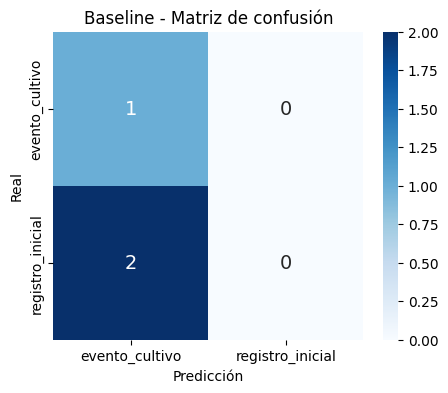

In [72]:
# Reporte como DataFrame (solo métricas por clase)
report_baseline = classification_report(
    y_test, y_pred,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

df_metrics = pd.DataFrame(report_baseline).transpose().iloc[:-3, :-1]

# Visualización tabular
display(df_metrics)

# Matriz de confusión (baseline - azul)
cm_baseline = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_baseline,
            annot=True,
            fmt="d",
            cmap="Blues",
            annot_kws={"size": 14},
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Baseline - Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

#### 4.7.2 Evaluación del modelo BETO

,precision,recall,f1-score
evento_cultivo,0.333333,1.0,0.5
registro_inicial,0.000000,0.0,0.0


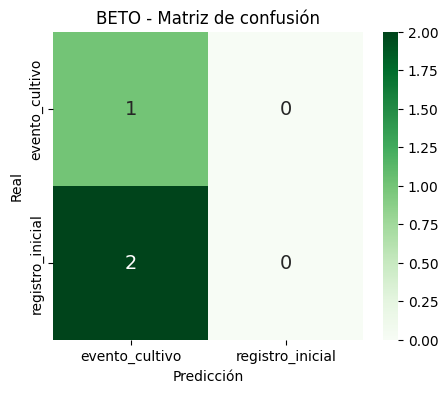

In [73]:
# Evaluación visual del modelo BETO
report_beto = classification_report(
    y_test, y_pred_beto,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

df_metrics_beto = pd.DataFrame(report_beto).transpose().iloc[:-3, :-1]

# Visualización tabular
display(df_metrics_beto)

# Matriz de confusión (BETO - verde)
cm_beto = confusion_matrix(y_test, y_pred_beto)

plt.figure(figsize=(5,4))
sns.heatmap(cm_beto,
            annot=True,
            fmt="d",
            cmap="Greens",
            annot_kws={"size": 14},
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("BETO - Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

#### 4.7.3 Comparación de modelos

PONER ESTO BIEN

En este apartado se comparan los resultados obtenidos por el modelo baseline y el modelo basado en BETO, utilizando las métricas de evaluación previamente calculadas sobre el conjunto de test.

El modelo baseline, basado en TF-IDF y regresión logística, proporciona una referencia inicial del rendimiento del sistema utilizando representaciones clásicas del texto. Por su parte, el modelo BETO permite incorporar información contextual más rica mediante el uso de representaciones profundas del lenguaje.

La comparación se centra en métricas como la exactitud global y el F1-score por clase, así como en el análisis de la matriz de confusión, lo que permite identificar posibles errores sistemáticos en la clasificación.

En esta fase preliminar, los resultados deben interpretarse con cautela debido al tamaño reducido del conjunto de datos, lo que limita la capacidad de generalización de ambos modelos. No obstante, este análisis permite establecer una base metodológica sólida para evaluar el impacto del uso de modelos más complejos cuando se disponga de un volumen de datos mayor y más equilibrado.

##### 4.7.3.1 Comparación de F1 por clase

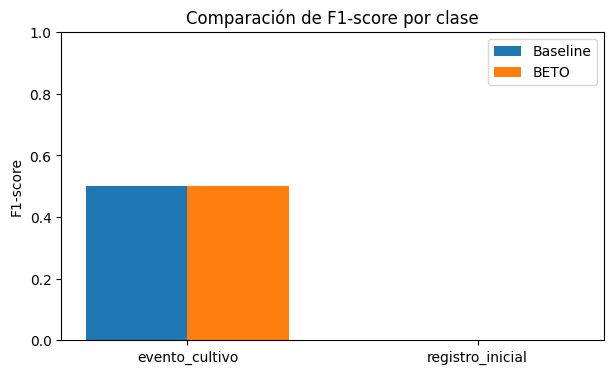

In [74]:
classes = list(label_encoder.classes_)

f1_baseline = [report_baseline[c]["f1-score"] for c in classes]
f1_beto = [report_beto[c]["f1-score"] for c in classes]

x = np.arange(len(classes))
width = 0.35

plt.figure(figsize=(7,4))
plt.bar(x - width/2, f1_baseline, width, label="Baseline")
plt.bar(x + width/2, f1_beto, width, label="BETO")

plt.xticks(x, classes)
plt.ylabel("F1-score")
plt.title("Comparación de F1-score por clase")
plt.legend()
plt.ylim(0,1)

plt.show()

##### 4.7.3.2 Comparación de accuracy

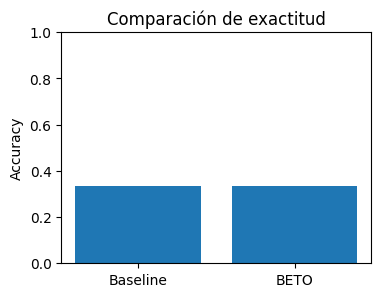

In [75]:
accuracy_baseline = report_baseline["accuracy"]
accuracy_beto = report_beto["accuracy"]

plt.figure(figsize=(4,3))
plt.bar(["Baseline", "BETO"], [accuracy_baseline, accuracy_beto])
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Comparación de exactitud")

plt.show()

##### 4.7.3.3 Diferencia de F1

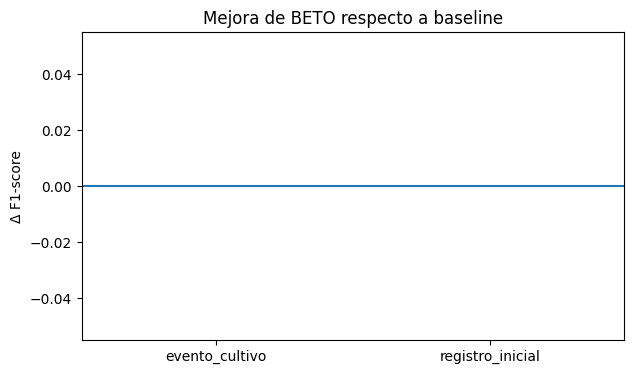

In [76]:
f1_diff = [b - a for a, b in zip(f1_baseline, f1_beto)]

plt.figure(figsize=(7,4))
plt.bar(classes, f1_diff)
plt.axhline(0)
plt.ylabel("Δ F1-score")
plt.title("Mejora de BETO respecto a baseline")

plt.show()

### 4.8 Aplicación sobre transcripciones ASR

aqui poner lo que se hace

## 5. Extracción de entidades (NER)

### 5.1 Definición de entidades

* `cultivo`, `producto`, `accion`, `problema`, `cantidad`, `fecha_evento`, etc.

### 5.2 Preparación del dataset

* anotación de textos

### 5.3 Enfoque

* modelo NER (spaCy / transformers)
* enfoque híbrido (modelo + reglas)

### 5.4 Inferencia

* extracción de entidades por texto

### 5.5 Evaluación

* precisión, recall, F1
* análisis de errores

## 6. Normalización de entidades (clave)

### 6.1 Problema

* variabilidad lingüística (LATAM)

### 6.2 Estrategia

* diccionario de sinónimos
* reglas de normalización

Ejemplo:

```text
abono / fertilizante → fertilizante
```

### 6.3 Aplicación

* transformación de entidades a formato estándar

## 7. Integración del pipeline

```text
texto → clasificación → NER → normalización → datos estructurados
```

* uso de la clase para guiar extracción

## 8. Generación de output final

```json
{
  "audio_id": "...",
  "user_id": "...",
  "transcription": "...",
  "clasificacion": "evento_cultivo",
  "entidades": {
    "accion": "...",
    "producto": "...",
    "cantidad": "...",
    "problema": "..."
  },
  "processing_version": "v1"
}
```

## 9. Análisis global de resultados

* distribución de clases
* calidad de entidades
* errores frecuentes

## 10. Selección del pipeline final

* justificación de:

  * modelo clasificación
  * modelo NER
  * reglas de normalización

## 11. Conclusiones
- Resumen del proceso aplicado
- Resultados principales
- Relevancia para el pipeline de Speech-to-Text

Te las defino, pero ojo: si no las acotas bien ahora, luego tendrás ruido y dataset inútil.

Voy a darte un **esquema mínimo pero sólido**, orientado a tu objetivo (modelo posterior).

---

# **Definición de entidades (NER) — Notebook 3**

## 🎯 Objetivo

Extraer información estructurada de los audios para construir un dataset útil para análisis y modelos predictivos.

---

## ✅ 1. Entidades de contexto (registro inicial)

Estas definen la “foto base” del productor:

* `cultivo` → café, cacao, maíz…
* `variedad` → arábica, robusta… (si aparece)
* `ubicacion` → finca, zona, comunidad
* `superficie` → hectáreas / extensión
* `edad_cultivo` → años / meses
* `sistema_produccion` → orgánico, convencional (si aplica)

---

## ✅ 2. Entidades de evento (núcleo del sistema)

Aquí está el valor real.

### 🔹 Acción

* `accion` → fertilización, riego, poda, fumigación, siembra, cosecha

### 🔹 Producto / insumo

* `producto` → urea, fungicida, abono, herbicida

### 🔹 Problema

* `problema` → plaga, enfermedad, sequía, exceso de lluvia

### 🔹 Cantidad

* `cantidad` → “2 sacos”, “5 litros”

### 🔹 Fecha / tiempo

* `fecha_evento` → ayer, hoy, hace 3 días

### 🔹 Estado del cultivo

* `estado` → bueno, malo, afectado, creciendo

---

## ✅ 3. Entidades ambientales (muy importantes)

* `clima` → lluvia, calor, sequía
* `condicion_suelo` → húmedo, seco (si aparece)

---

## ✅ 4. Entidades auxiliares (opcionales pero útiles)

* `frecuencia` → cada semana, una vez al mes
* `intensidad` → mucho, poco
* `observacion` → texto libre relevante

---

# 🧠 Ejemplo real

Audio:

> “ayer eché dos sacos de urea porque vi una plaga”

Salida:

```json
{
  "accion": "fertilizacion",
  "producto": "urea",
  "cantidad": "2 sacos",
  "fecha_evento": "ayer",
  "problema": "plaga"
}
```

